In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset
dataset=pd.read_csv("/content/drive/MyDrive/422 dataset/telco_customer_churn.csv")


# Output: Number of data points
print(" Number of data points (samples):", dataset.shape[0])
print(" Number of features (excluding target):", dataset.shape[1] - 1)

 Number of data points (samples): 7043
 Number of features (excluding target): 20


In [ ]:
dataset

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
# Identify categorical and quantitative features
categorical_features = dataset.select_dtypes(include='object').columns.tolist()
quantitative_features = dataset.select_dtypes(include=np.number).columns.tolist()

print("\n Categorical Features:")
print(categorical_features)

print("\n Quantitative Features:")
print(quantitative_features)





 Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

 Quantitative Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


/tmp/ipython-input-1246238697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=dataset, palette='Set2')


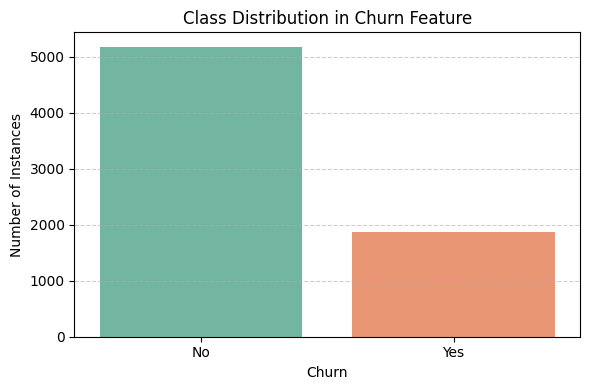

Class Distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=dataset, palette='Set2')

plt.title("Class Distribution in Churn Feature")
plt.xlabel("Churn")
plt.ylabel("Number of Instances")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


print("Class Distribution:\n", dataset['Churn'].value_counts())


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
dataset.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [ ]:
##Selecting numerical features
numerical_data = dataset.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 3 numerical features: 

['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [ ]:
#Selecting categoricalfeatures
categorical_data=dataset.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} numerical features:', '\n')
print(categorical_features)

There are 18 numerical features: 

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [ ]:
# Transposed stats for numerical features

numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
dataset.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
numerical_data.var()

,0
SeniorCitizen,0.135875
tenure,603.168108
MonthlyCharges,905.410934


In [ ]:
numerical_data.skew()

,0
SeniorCitizen,1.833633
tenure,0.239540
MonthlyCharges,-0.220524


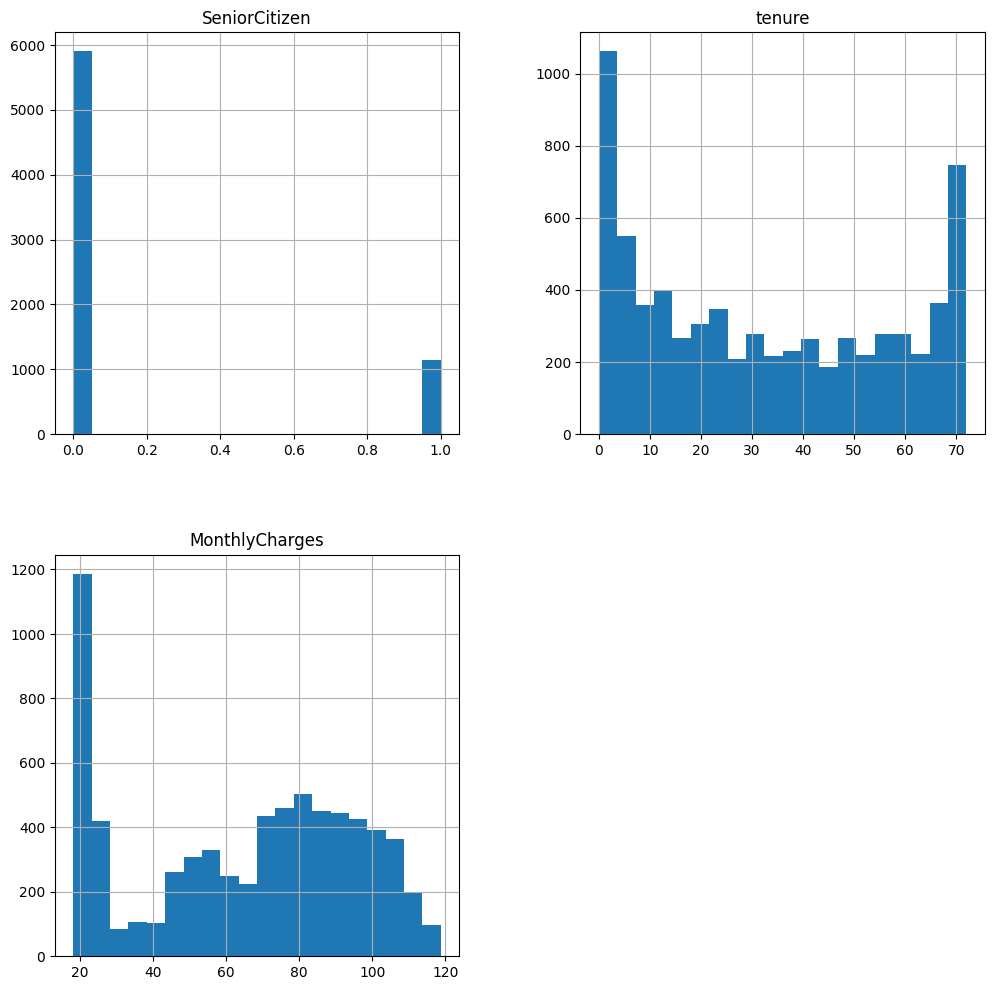

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

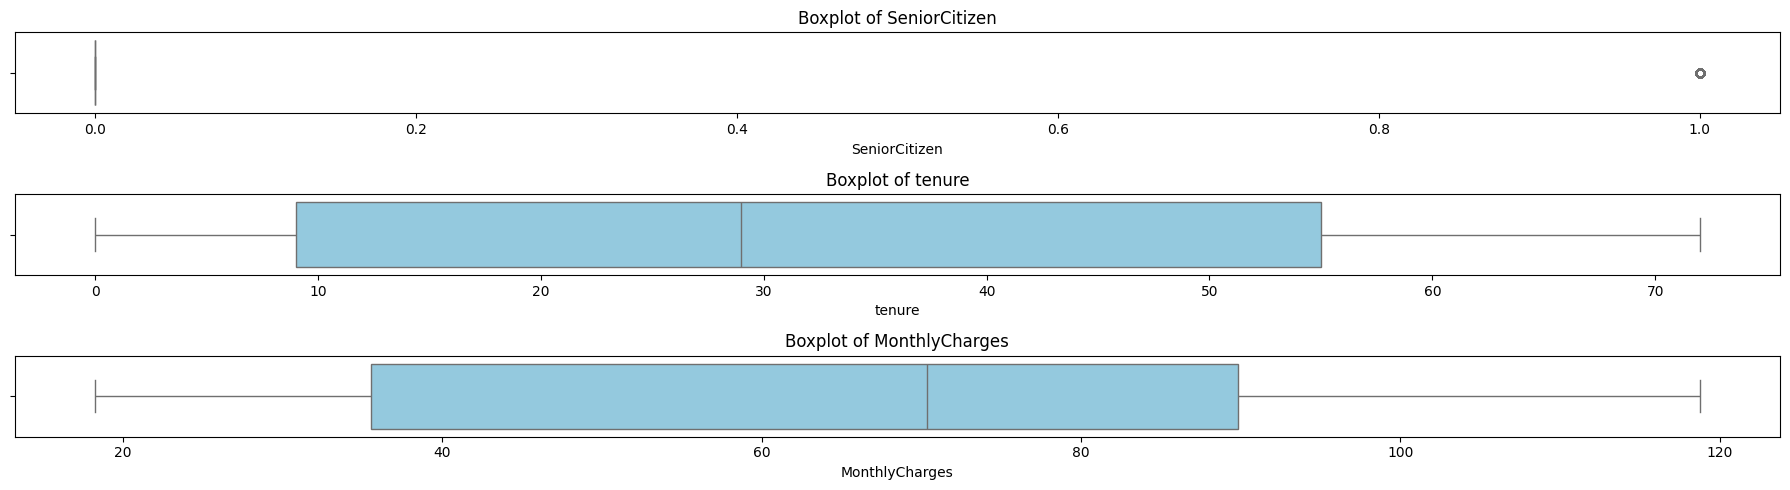

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(18, 5))

# Plot boxplots for each numerical feature
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

In [ ]:
# Select only numerical columns
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

print("Total number of outliers per numeric column:\n")

for col in numeric_cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outlier_count = dataset[(dataset[col] < lower_bound) | (dataset[col] > upper_bound)][col].count()

    print(f"{col}: {outlier_count} outlier(s)")


Total number of outliers per numeric column:

SeniorCitizen: 1142 outlier(s)
tenure: 0 outlier(s)
MonthlyCharges: 0 outlier(s)


In [ ]:
# unique values counts
unique_counts=categorical_data.nunique()
print(unique_counts)

customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
TotalCharges        6531
Churn                  2
dtype: int64


In [ ]:
# for col in categorical_features:
#     plt.title(f'Distribution of {col}')
#     categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
#     plt.show()

In [ ]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
correlation_matrix


,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


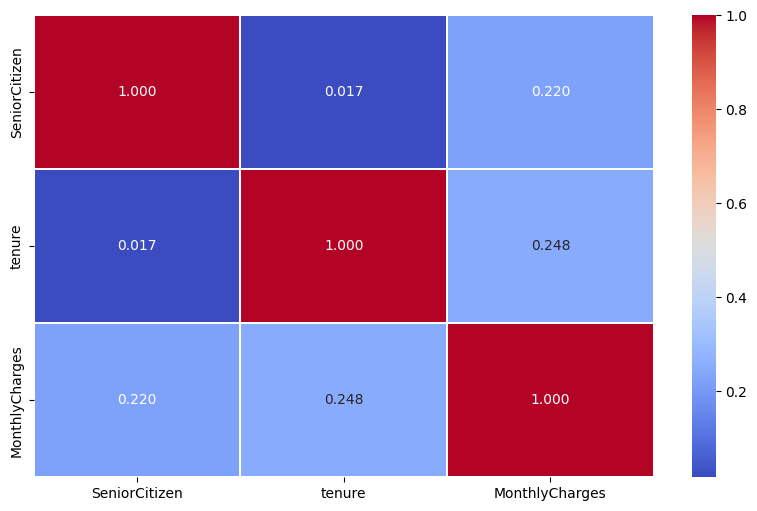

In [ ]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

In [ ]:
# DATA PRE PROCESSING
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')


print(" Missing values before deletion:\n", dataset.isnull().sum())


dataset.dropna(inplace=True)


print("\n Missing values after deletion:\n", dataset.isnull().sum())


#  Encoding Categorical Values



dataset.drop('customerID', axis=1, inplace=True)


binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
multi_class_cols = [col for col in dataset.select_dtypes(include='object').columns if col not in binary_cols]


le = LabelEncoder()
for col in binary_cols:
    dataset[col] = le.fit_transform(dataset[col])

# One-hot encode multiclass categorical features
dataset = pd.get_dummies(dataset, columns=multi_class_cols, drop_first=False)


# Feature Scaling


num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']


scaler = StandardScaler()


dataset[num_cols] = scaler.fit_transform(dataset[num_cols])




print("\n Final columns after encoding and scaling:")
print(dataset.columns.tolist())


# print("\n Sample of Preprocessed Data:")
# print(dataset.head())

 Missing values before deletion:
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

 Missing values after deletion:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges      

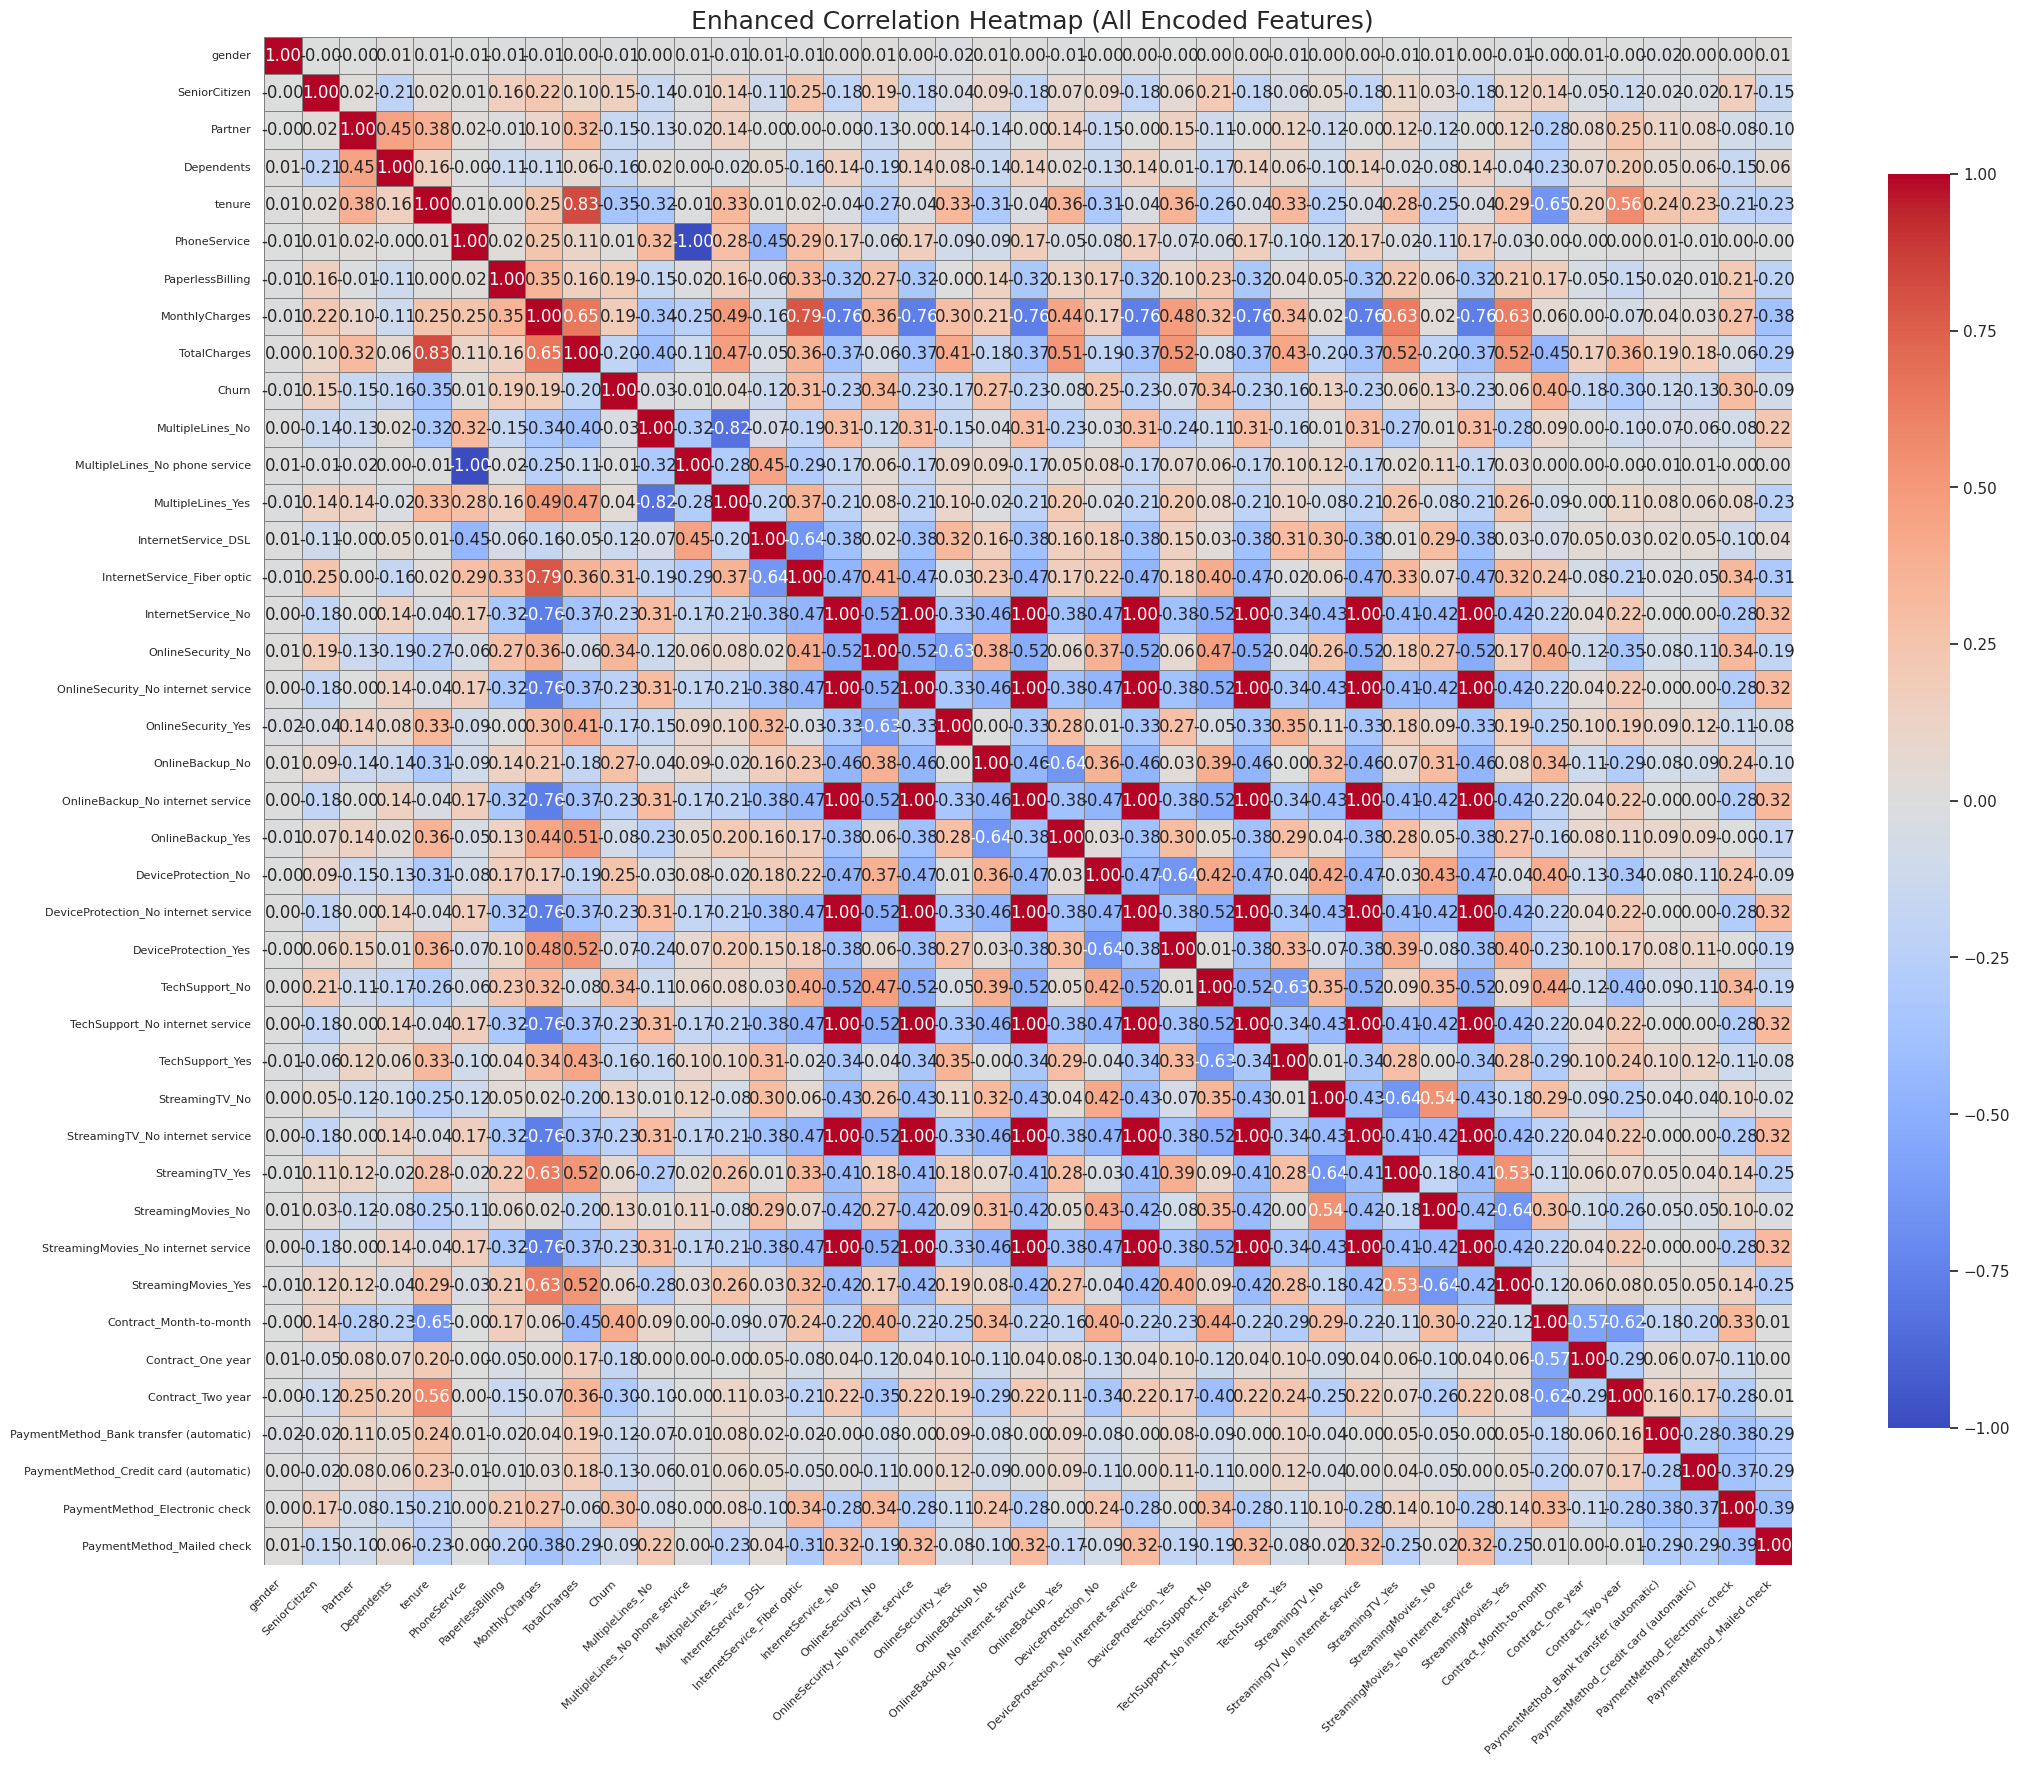

In [ ]:

correlation_matrix = dataset.corr()


plt.figure(figsize=(22, 18))
sns.set(style='white')
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'shrink': 0.8},
    vmax=1.0,
    vmin=-1.0,
    square=True
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(" Enhanced Correlation Heatmap (All Encoded Features)", fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:

lst=['InternetService_No','OnlineSecurity_No internet service','OnlineBackup_No internet service','DeviceProtection_No internet service','TechSupport_No internet service','StreamingTV_No internet service',"MultipleLines_No phone service"]
dataset=dataset.drop(lst, axis=1)

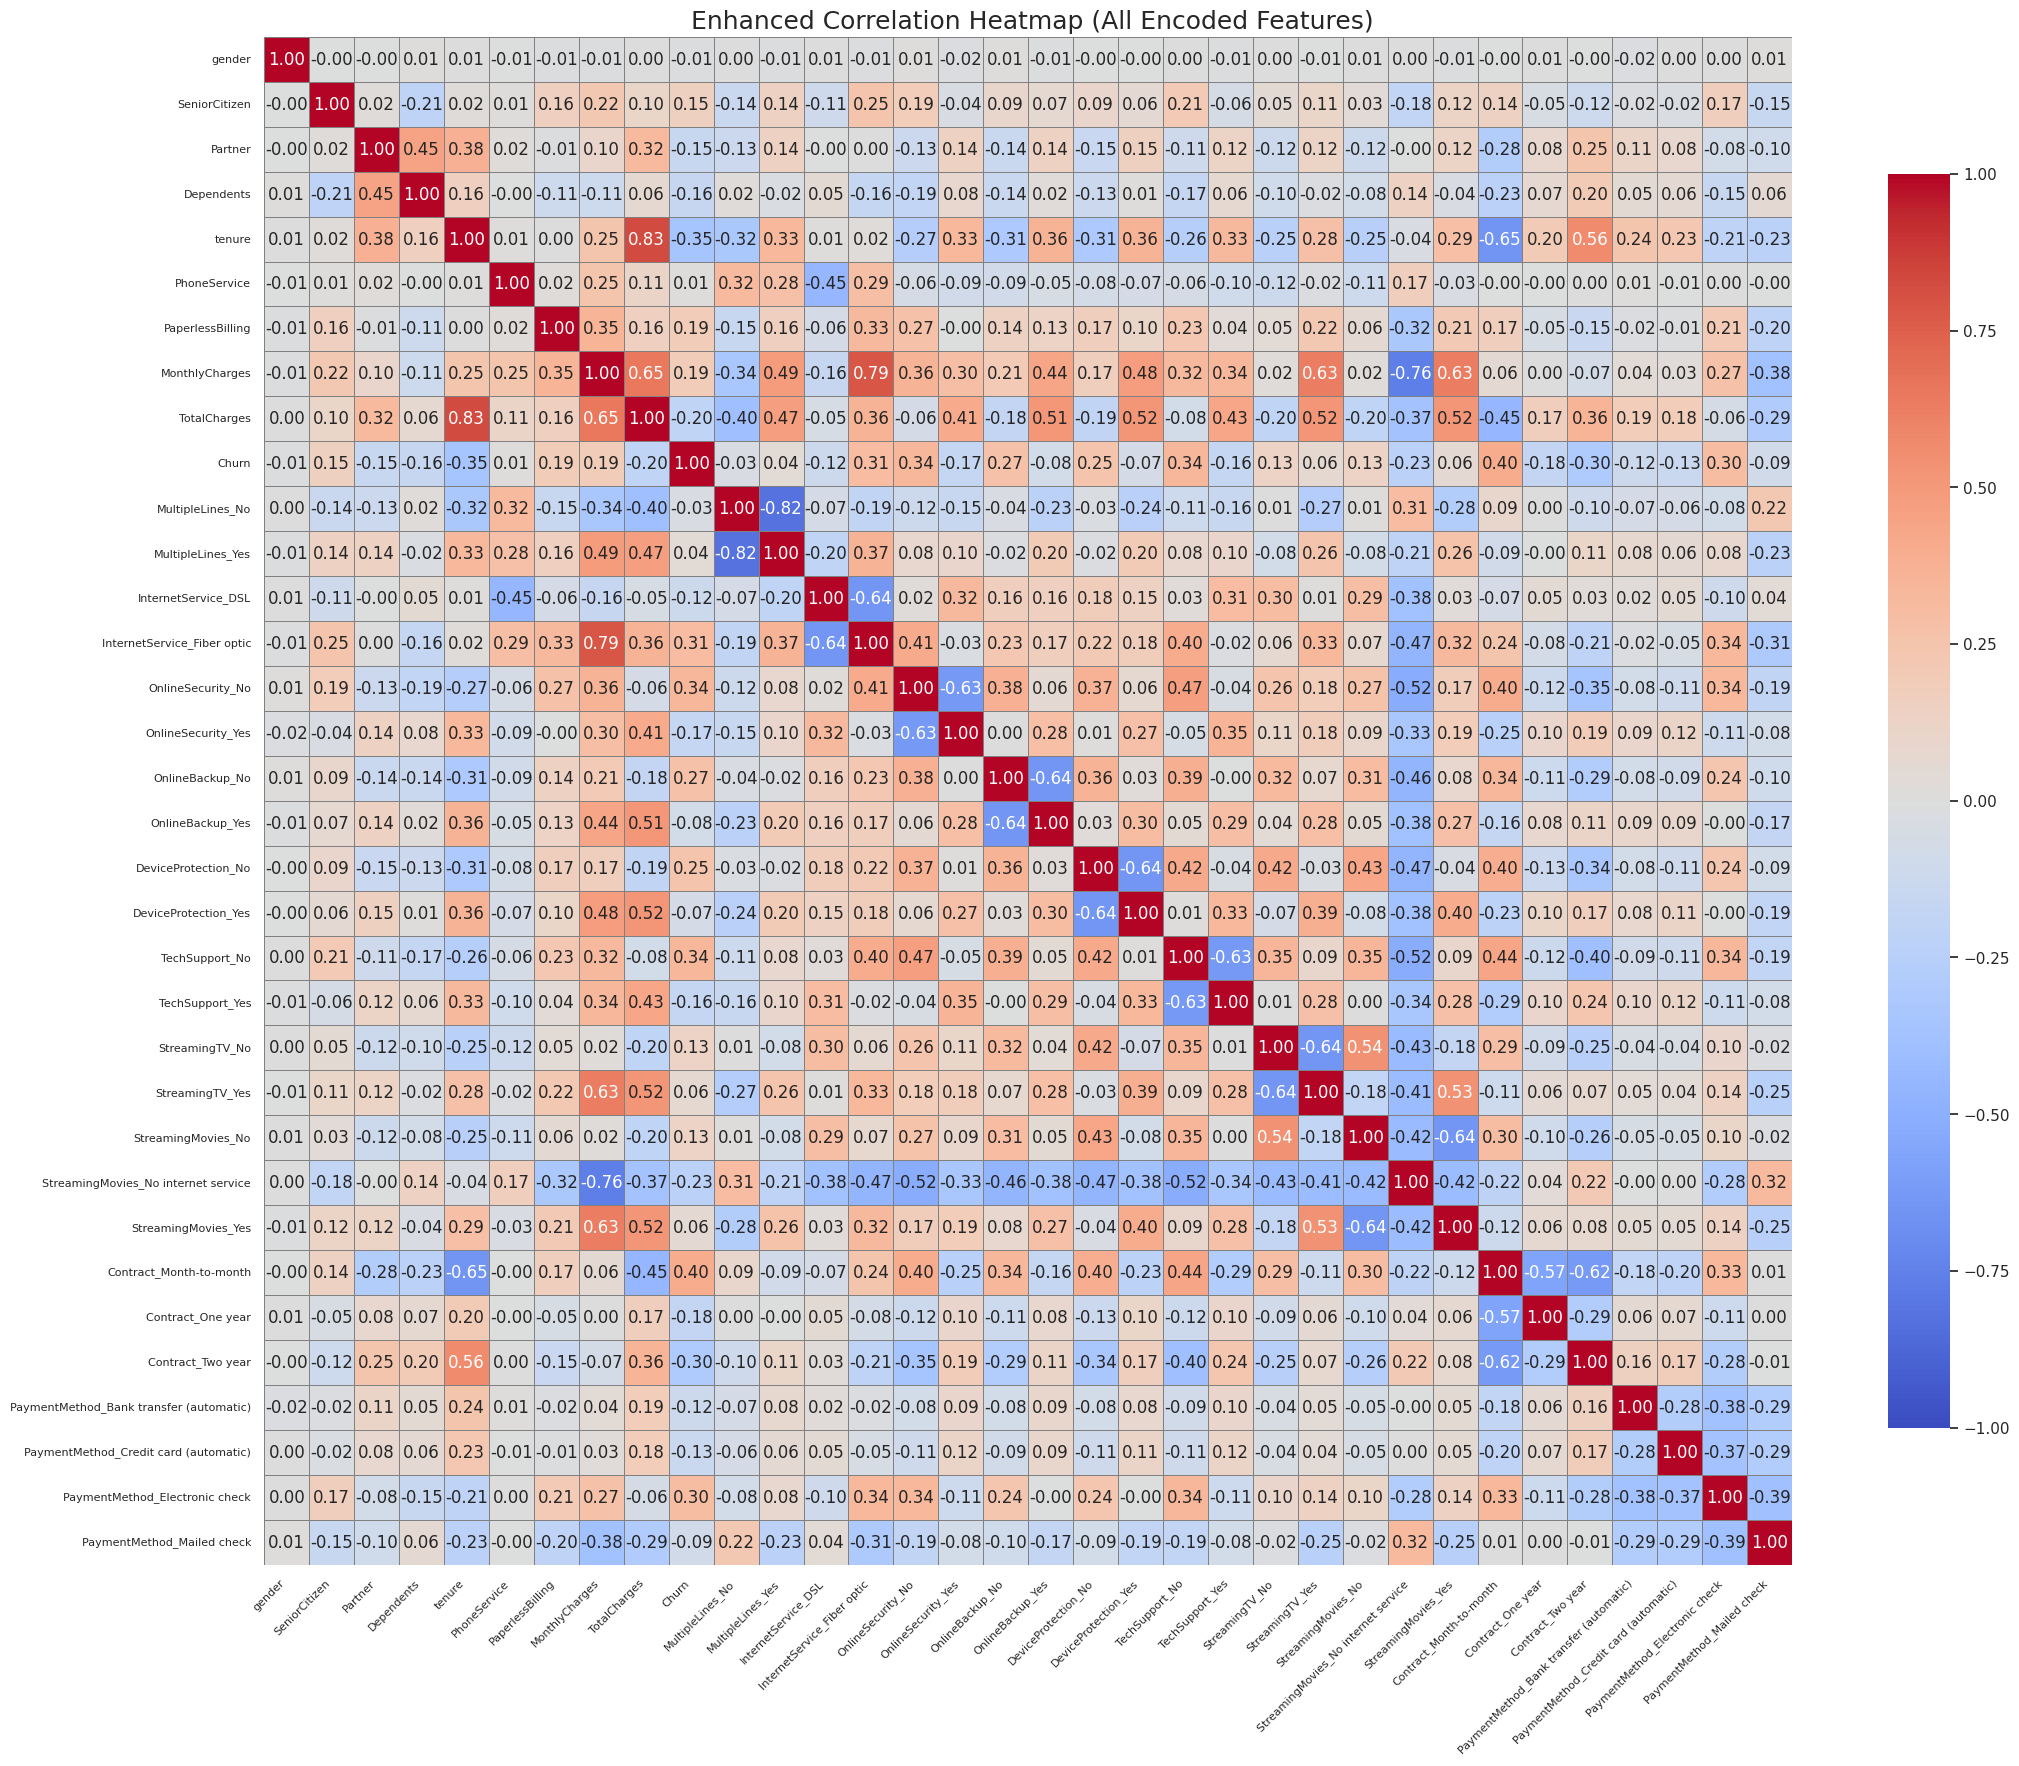

In [ ]:
correlation_matrix_2 = dataset.corr()


plt.figure(figsize=(22, 18))
sns.set(style='white')
sns.heatmap(
    correlation_matrix_2,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'shrink': 0.8},
    vmax=1.0,
    vmin=-1.0,
    square=True
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(" Enhanced Correlation Heatmap (All Encoded Features)", fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split


X = dataset.drop('Churn', axis=1)
y = dataset['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

#Kn neighbor
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


knn_preds = knn.predict(X_test)
print(" KNN Accuracy:", accuracy_score(y_test, knn_preds))
print(" KNN Classification Report:\n", classification_report(y_test, knn_preds))


 KNN Accuracy: 0.7630331753554502
 KNN Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84      1549
           1       0.56      0.55      0.55       561

    accuracy                           0.76      2110
   macro avg       0.70      0.69      0.69      2110
weighted avg       0.76      0.76      0.76      2110



In [ ]:
from sklearn.linear_model import LogisticRegression

#logistic
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)


lr_preds = lr.predict(X_test)
print(" Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print(" Logistic Regression Classification Report:\n", classification_report(y_test, lr_preds))


 Logistic Regression Accuracy: 0.8052132701421801
 Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.65      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7112 - loss: 0.5779 - val_accuracy: 0.7924 - val_loss: 0.4428
Epoch 2/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4343 - val_accuracy: 0.7962 - val_loss: 0.4369
Epoch 3/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7990 - loss: 0.4242 - val_accuracy: 0.8005 - val_loss: 0.4342
Epoch 4/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8025 - loss: 0.4058 - val_accuracy: 0.8000 - val_loss: 0.4327
Epoch 5/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8035 - loss: 0.4046 - val_accuracy: 0.8019 - val_loss: 0.4331
Epoch 6/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8125 - loss: 0.3954 - val_accuracy: 0.7986 - val_loss: 0.4316
Epoch 7/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8097 - loss: 0.4051 - val_accuracy: 0.7995 - val_loss: 0.4313
Epoch 8/25
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8193 - loss: 0.3920 - val_accuracy: 0.8005 - val_loss:

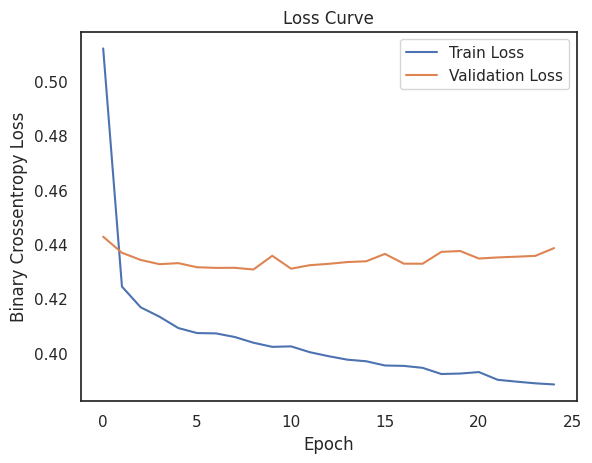

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7901 - loss: 0.4528
Test Accuracy: 79.57%


In [ ]:
# Neural network model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=25, batch_size=64, validation_data=(X_test, y_test))


plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.show()


loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

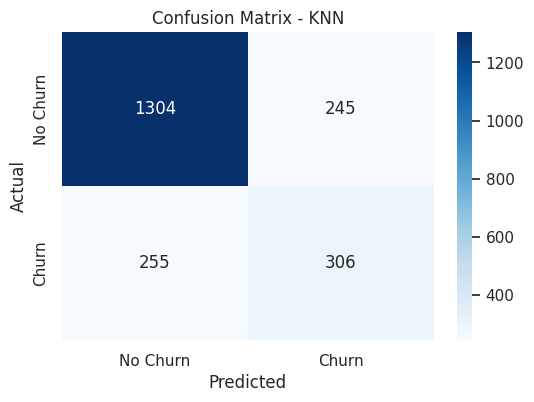

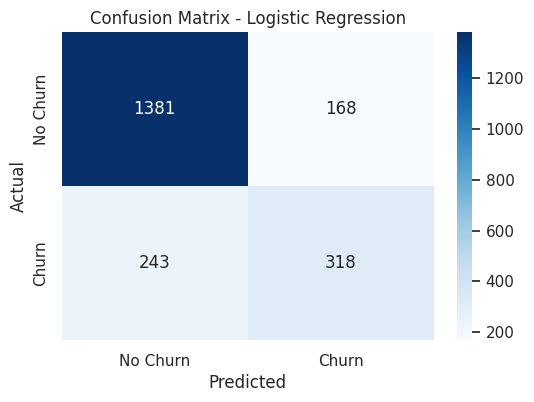

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


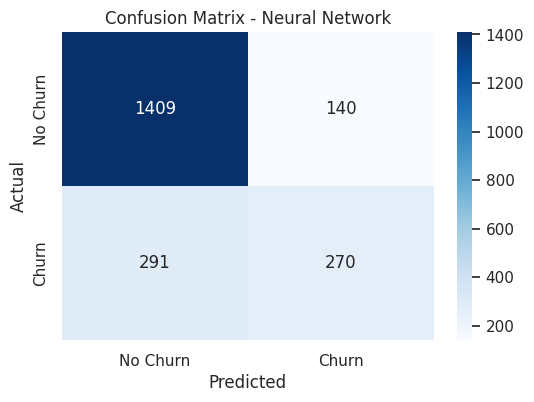

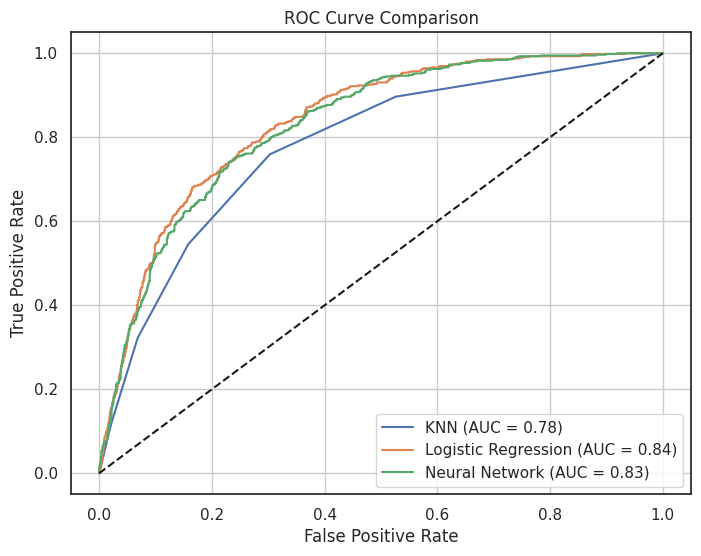

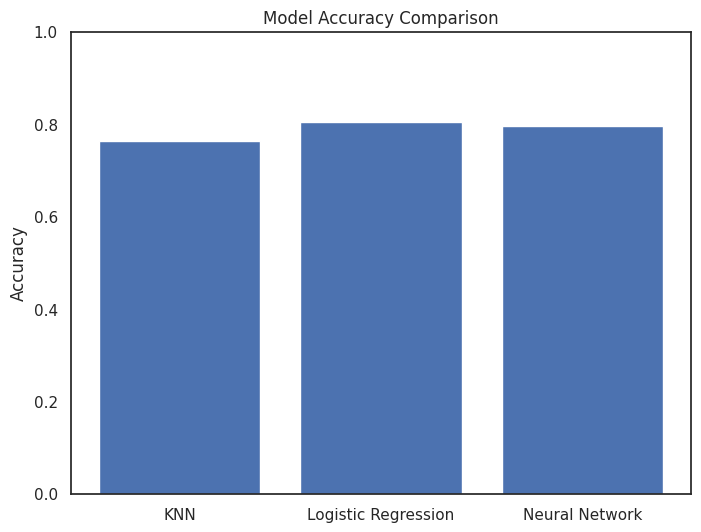

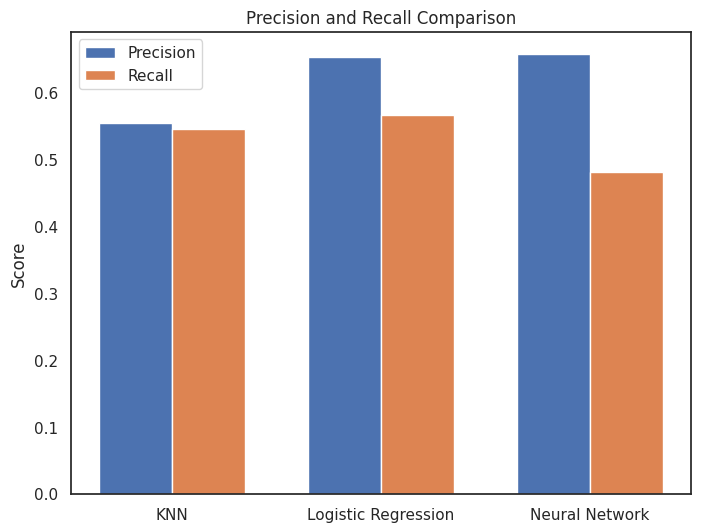

In [ ]:
model_results = {}
roc_data = {}

# Evaluate models and store results
models = {
    "KNN": knn,
    "Logistic Regression": lr,
    "Neural Network": model
}

for model_name, model in models.items():
    if model_name == "Neural Network":
        y_pred_prob = model.predict(X_test)
        y_pred = (y_pred_prob > 0.5).astype("int32")
        y_prob = y_pred_prob
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]


    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    model_results[model_name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    }

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # ROC Curve data
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[model_name] = (fpr, tpr, roc_auc)


plt.figure(figsize=(8, 6))
for model_name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Bar chart for accuracy comparison
plt.figure(figsize=(8, 6))
plt.bar(model_results.keys(), [result["accuracy"] for result in model_results.values()])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# Precision and Recall Comparison
plt.figure(figsize=(8, 6))
width = 0.35
x = list(model_results.keys())
precision_values = [result["precision"] for result in model_results.values()]
recall_values = [result["recall"] for result in model_results.values()]

plt.bar(x, precision_values, width, label='Precision')
plt.bar([i + width for i in range(len(x))], recall_values, width, label='Recall')

plt.ylabel('Score')
plt.title('Precision and Recall Comparison')
plt.xticks([i + width / 2 for i in range(len(x))], x)
plt.legend()
plt.show()
